# Breast Cancer Prediction Project

Welcome to the Breast Cancer Prediction project! 🎯

In this beginner-friendly notebook, we'll walk through a step-by-step machine learning pipeline to predict whether a tumor is malignant or benign based on various features.

## 🔍 Objective

Our goal is to build a machine learning model that can accurately predict whether a tumor is **malignant (M)** or **benign (B)** based on a set of measurements.

We'll use the dataset `Cancer_Data.csv` for this purpose.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

## 📥 Step 1: Load the Dataset

In [2]:
df = pd.read_csv(r"C:\Users\st203\INTERNSHIP\diabetes project\Cancer_Data.csv")

In [3]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## 🔍 Step 2: Explore the Dataset

In [4]:
# shape of the dataset

df.shape

(569, 33)

* We have 569 rows and 3 columns in the dataset.

In [5]:
# check the null values in data

df.isnull().sum().sum()

569

* We have 569 null values in our dataset.

In [6]:
# Check for duplicates 

df.duplicated().sum()

0

In [7]:
# Check some basic information about dataset 

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [8]:
# statistical summary 

df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


## 🧹 Step 3: Clean the Data

We'll remove any unnecessary columns and handle missing values.

In [9]:
# Drop the 'Unnamed: 32' column and 'id'

df.drop('Unnamed: 32',axis=1,inplace=True)

In [10]:
df.drop('id',axis=1,inplace=True)

In [11]:
df.isnull().sum().sum()

0

## 📊 Step 4: Visualize the Data

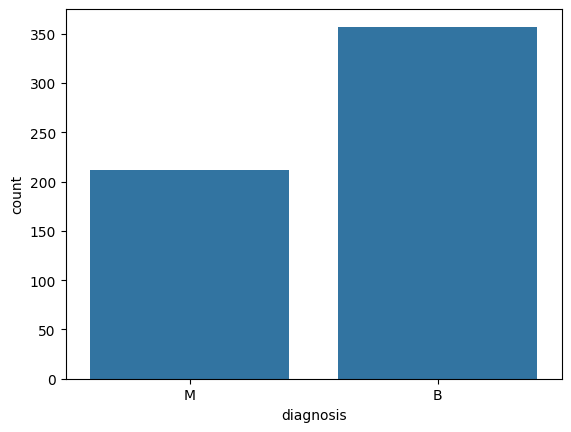

In [12]:
sns.countplot(x='diagnosis',data=df)
plt.show()

* Here we can see tumor benign (B) is high in the dataset.

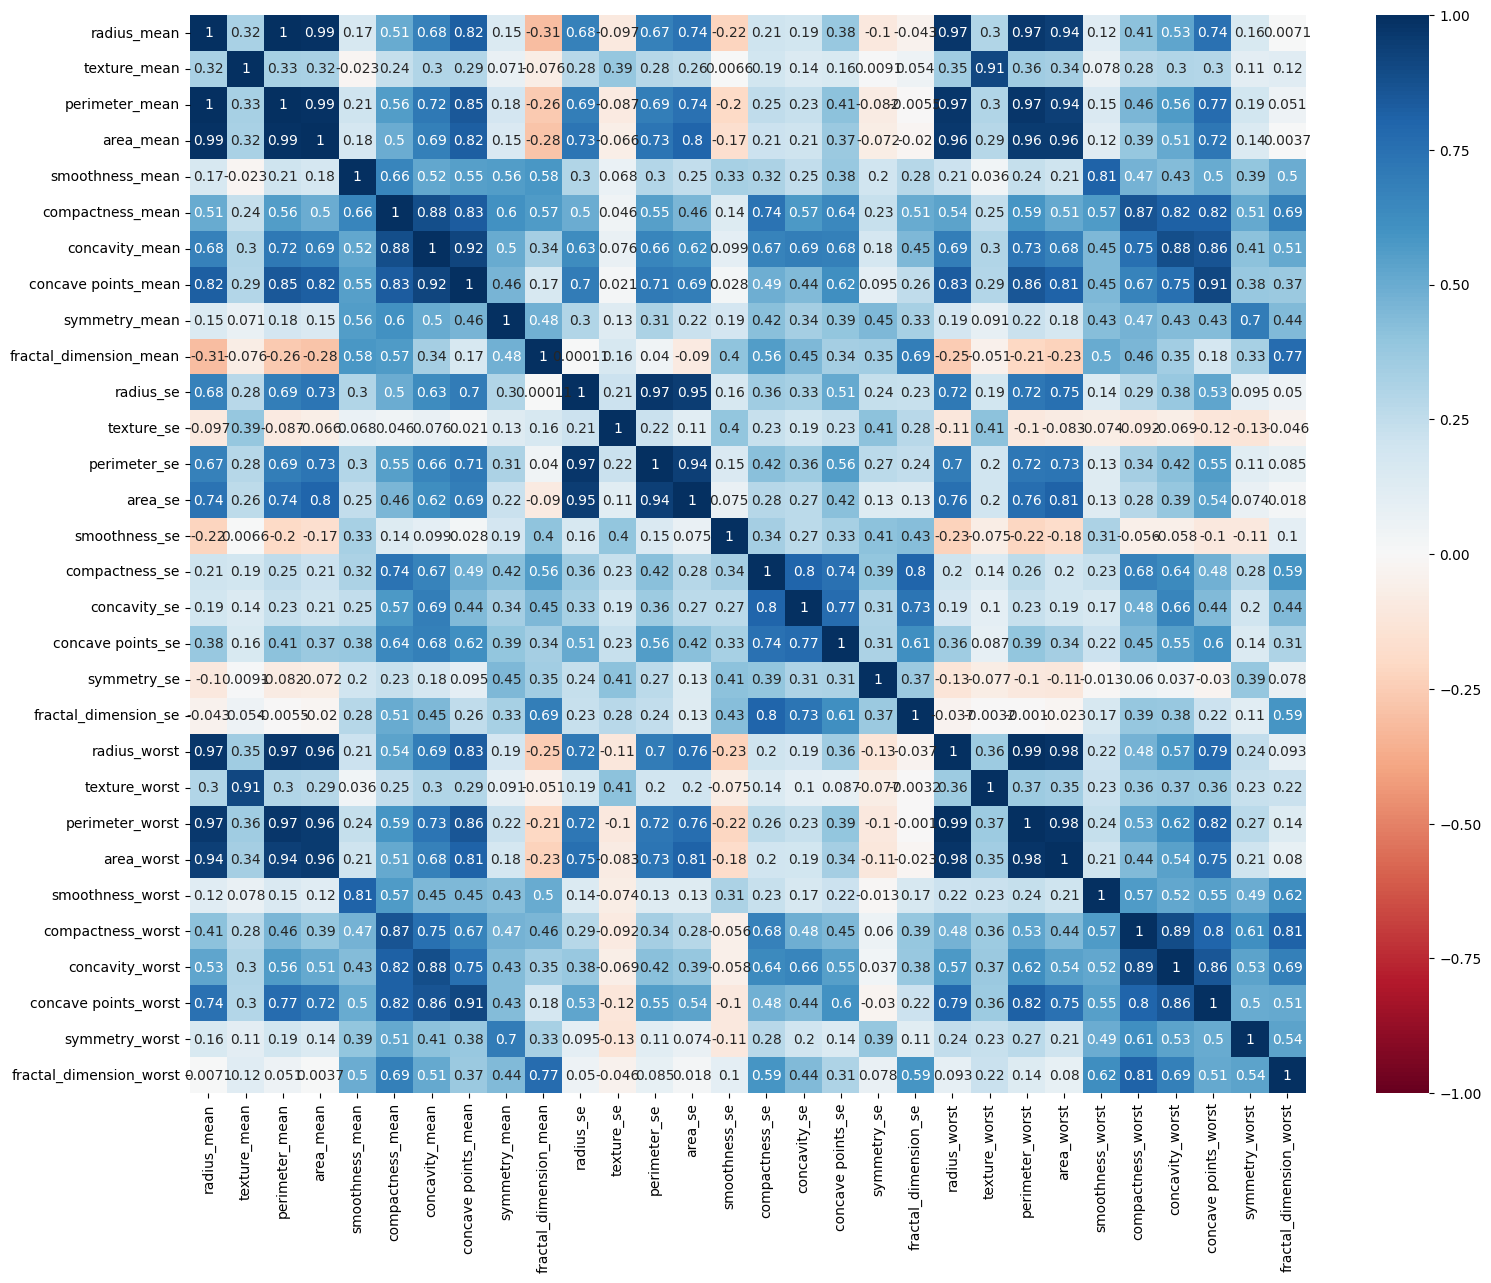

In [13]:
plt.figure(figsize=[18,14])
sns.heatmap(df.corr(numeric_only=True),annot=True,vmax=1,vmin=-1,cmap='RdBu')
plt.show()

* Features like (concave points_worst, perimeter_worst, concave points_mean, radius_worst, perimeter_mean) are most positively correlated with target variable.

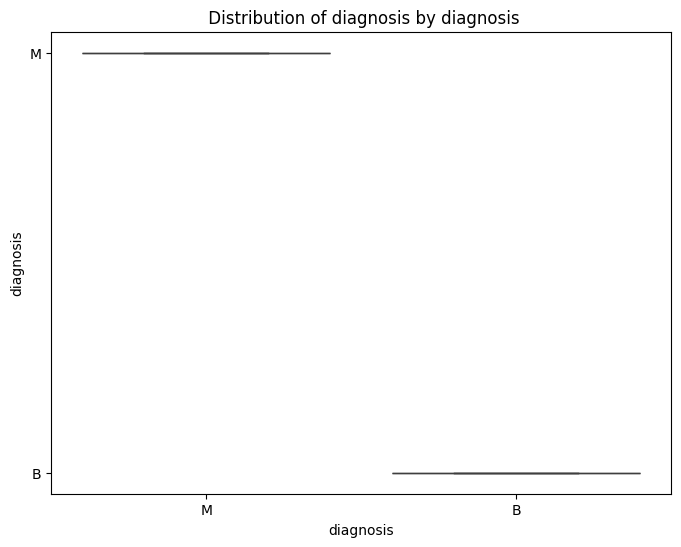

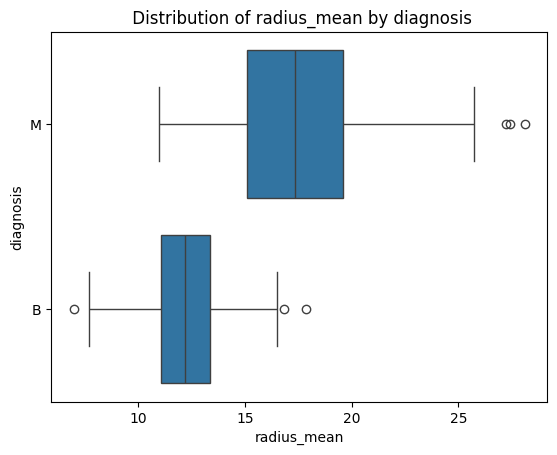

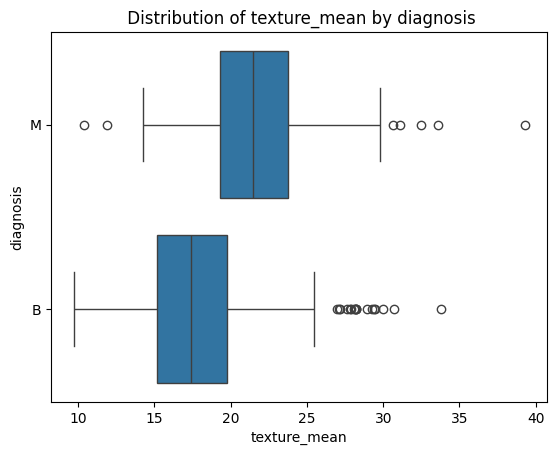

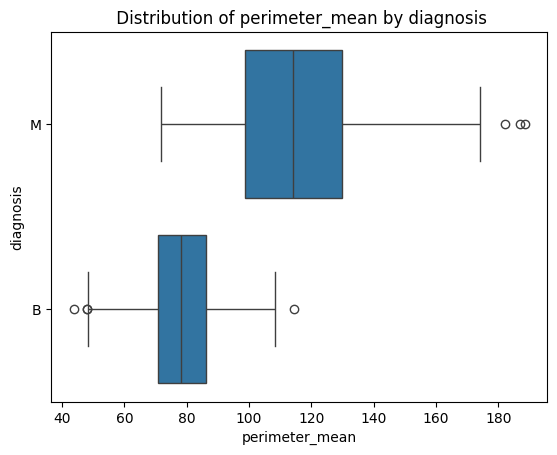

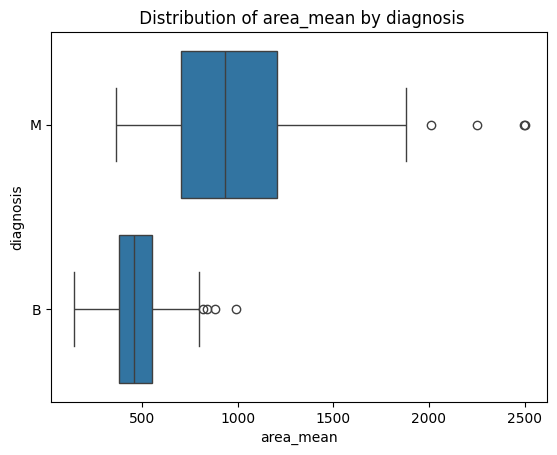

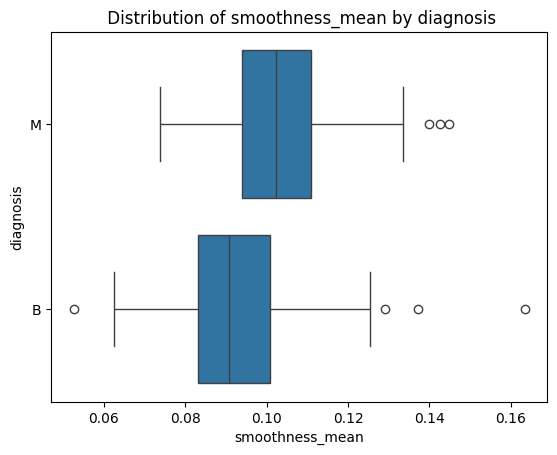

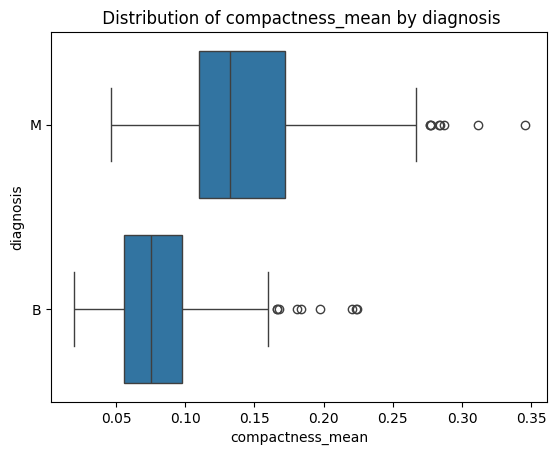

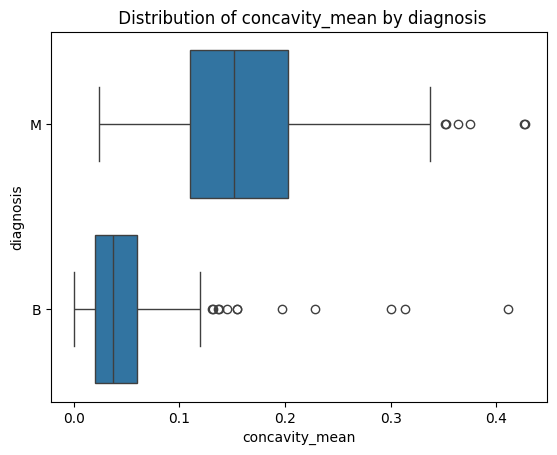

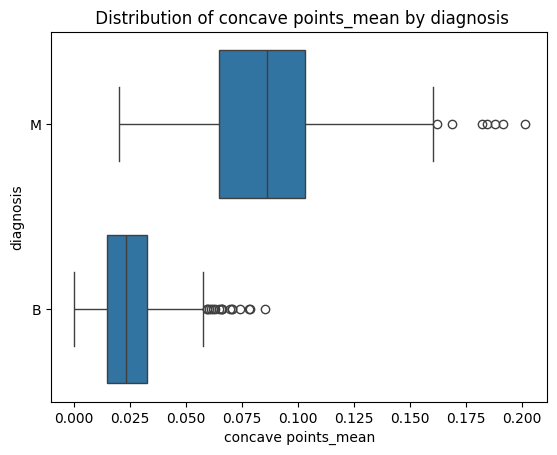

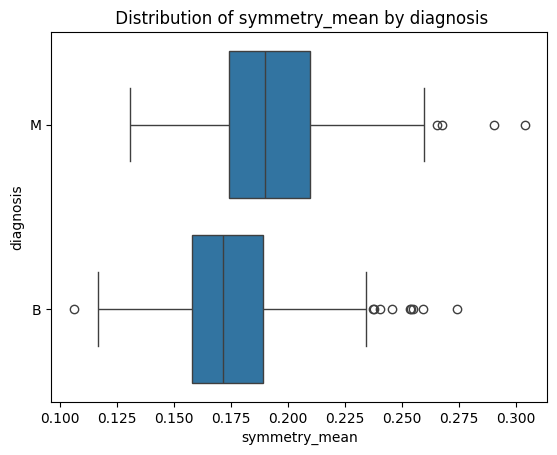

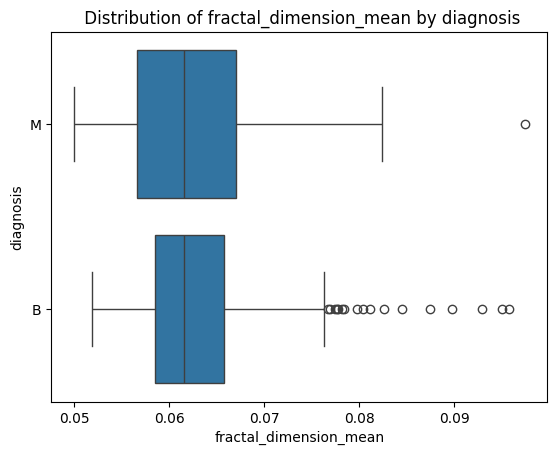

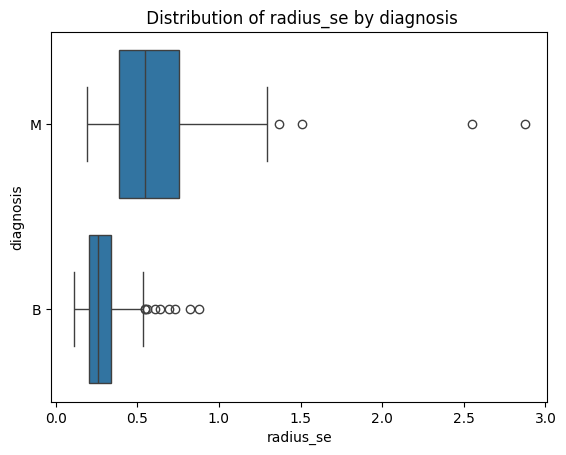

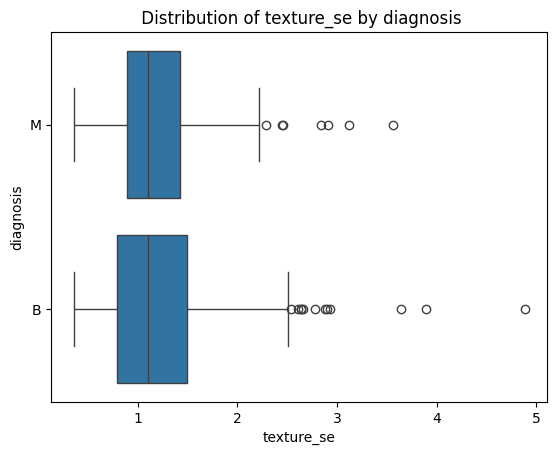

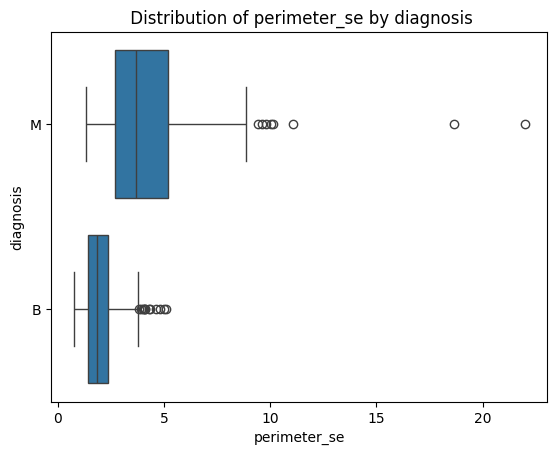

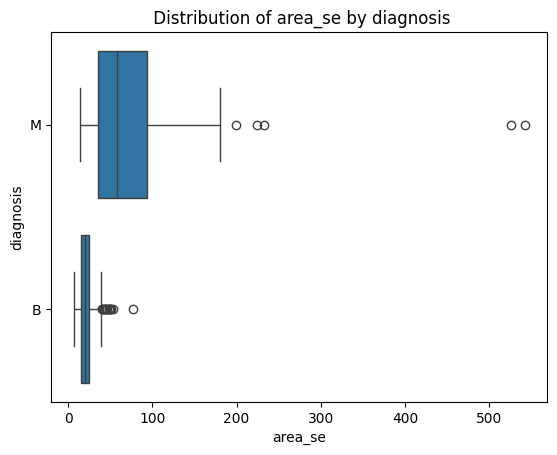

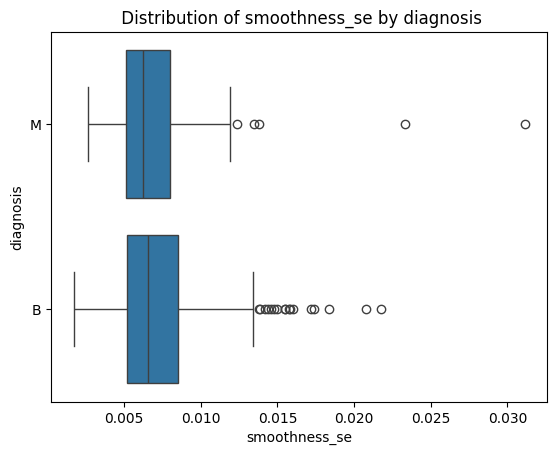

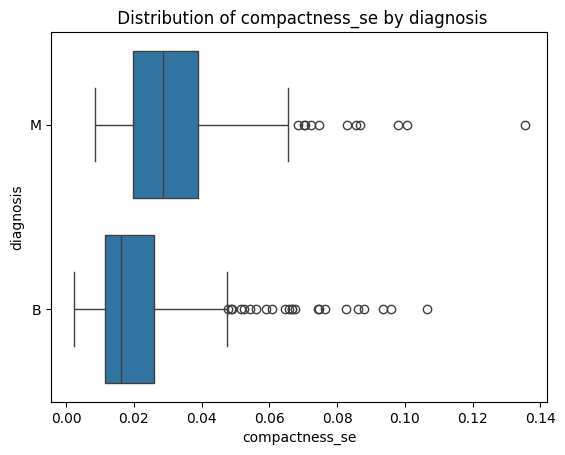

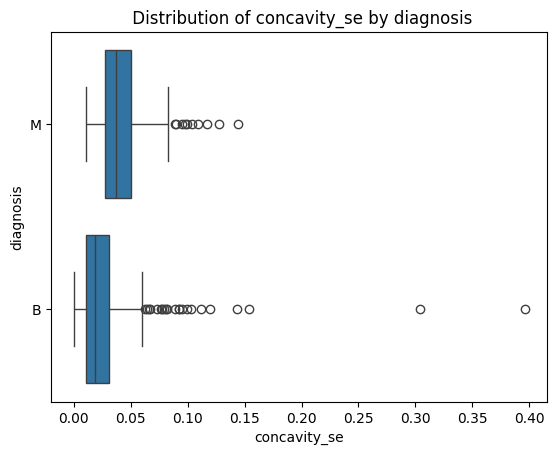

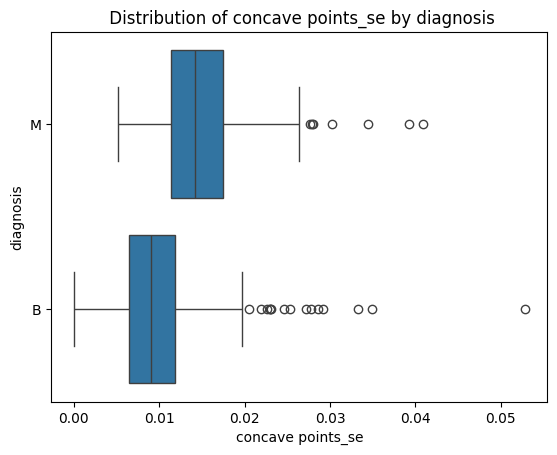

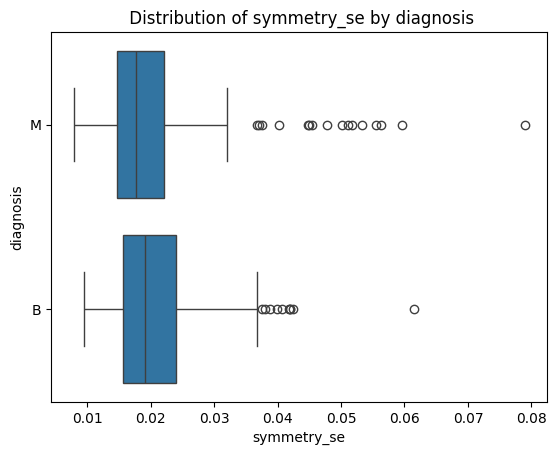

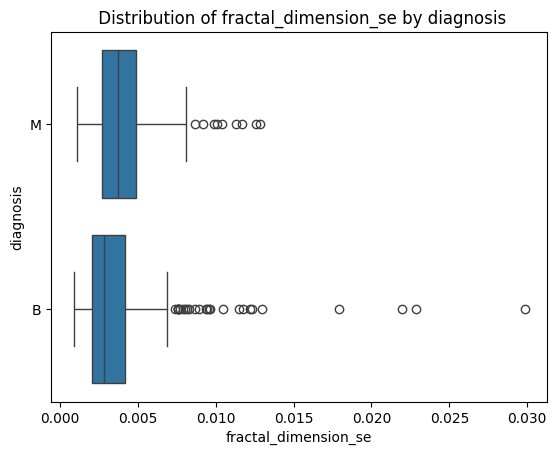

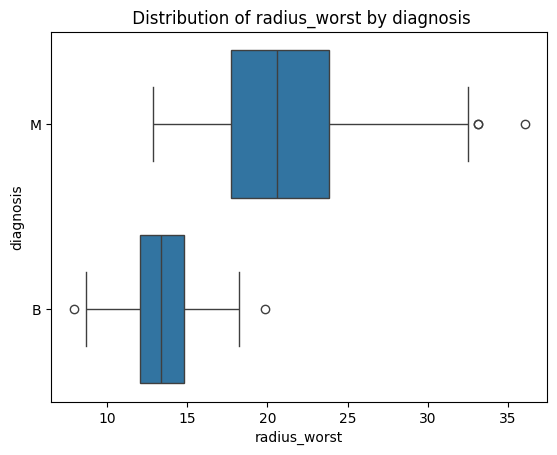

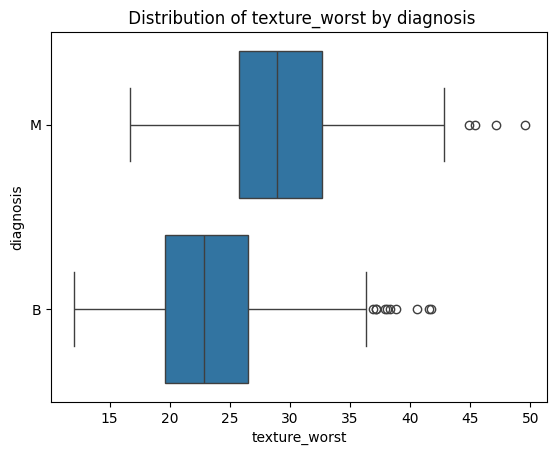

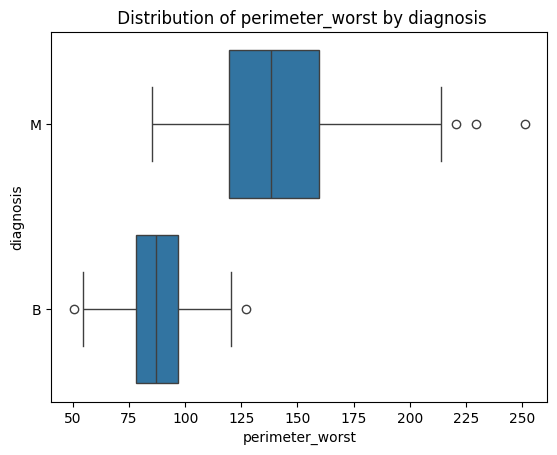

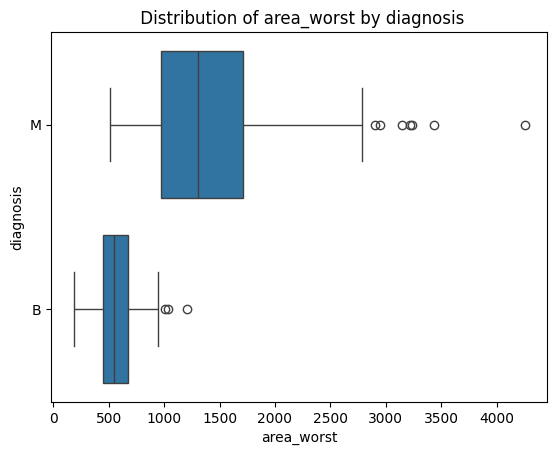

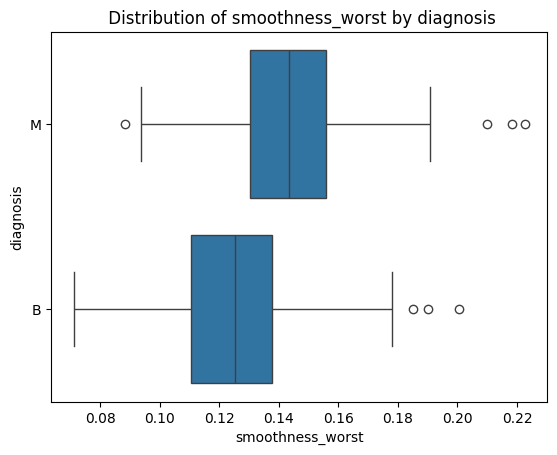

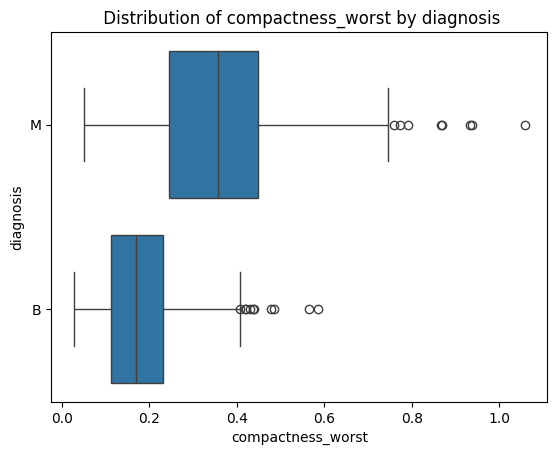

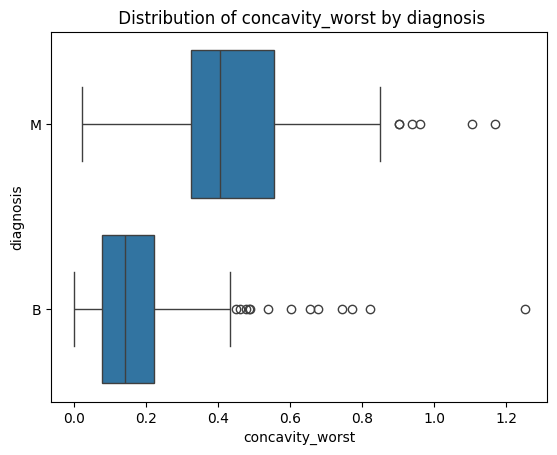

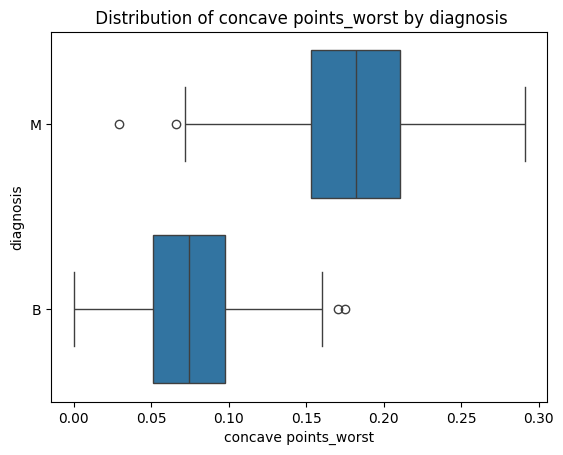

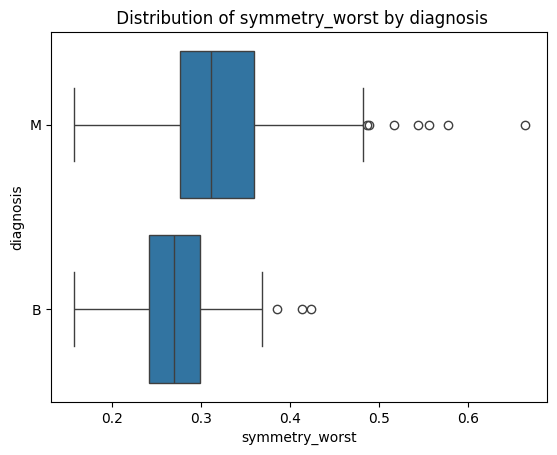

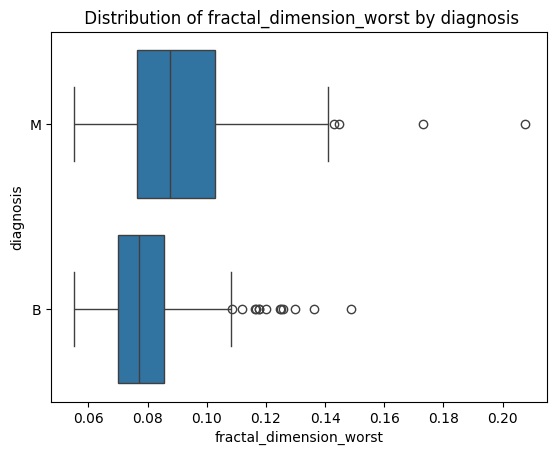

In [14]:
plt.figure(figsize=(8, 6))
for i in df:
    sns.boxplot(x=i, y='diagnosis', data=df,)
    plt.title(f" Distribution of {i} by diagnosis")
    plt.show()

In [15]:
df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [19]:
list = ['radius_mean','concave points_mean','area_mean','perimeter_mean','concavity_mean','diagnosis']
list

['radius_mean',
 'concave points_mean',
 'area_mean',
 'perimeter_mean',
 'concavity_mean',
 'diagnosis']

In [21]:
# Making a seperate data for pairplot

for_pairplot = df[list]
for_pairplot

,radius_mean,concave points_mean,area_mean,perimeter_mean,concavity_mean,diagnosis
0,17.99,0.14710,1001.0,122.80,0.30010,M
1,20.57,0.07017,1326.0,132.90,0.08690,M
2,19.69,0.12790,1203.0,130.00,0.19740,M
3,11.42,0.10520,386.1,77.58,0.24140,M
4,20.29,0.10430,1297.0,135.10,0.19800,M
...,...,...,...,...,...,...
564,21.56,0.13890,1479.0,142.00,0.24390,M
565,20.13,0.09791,1261.0,131.20,0.14400,M
566,16.60,0.05302,858.1,108.30,0.09251,M
567,20.60,0.15200,1265.0,140.10,0.35140,M


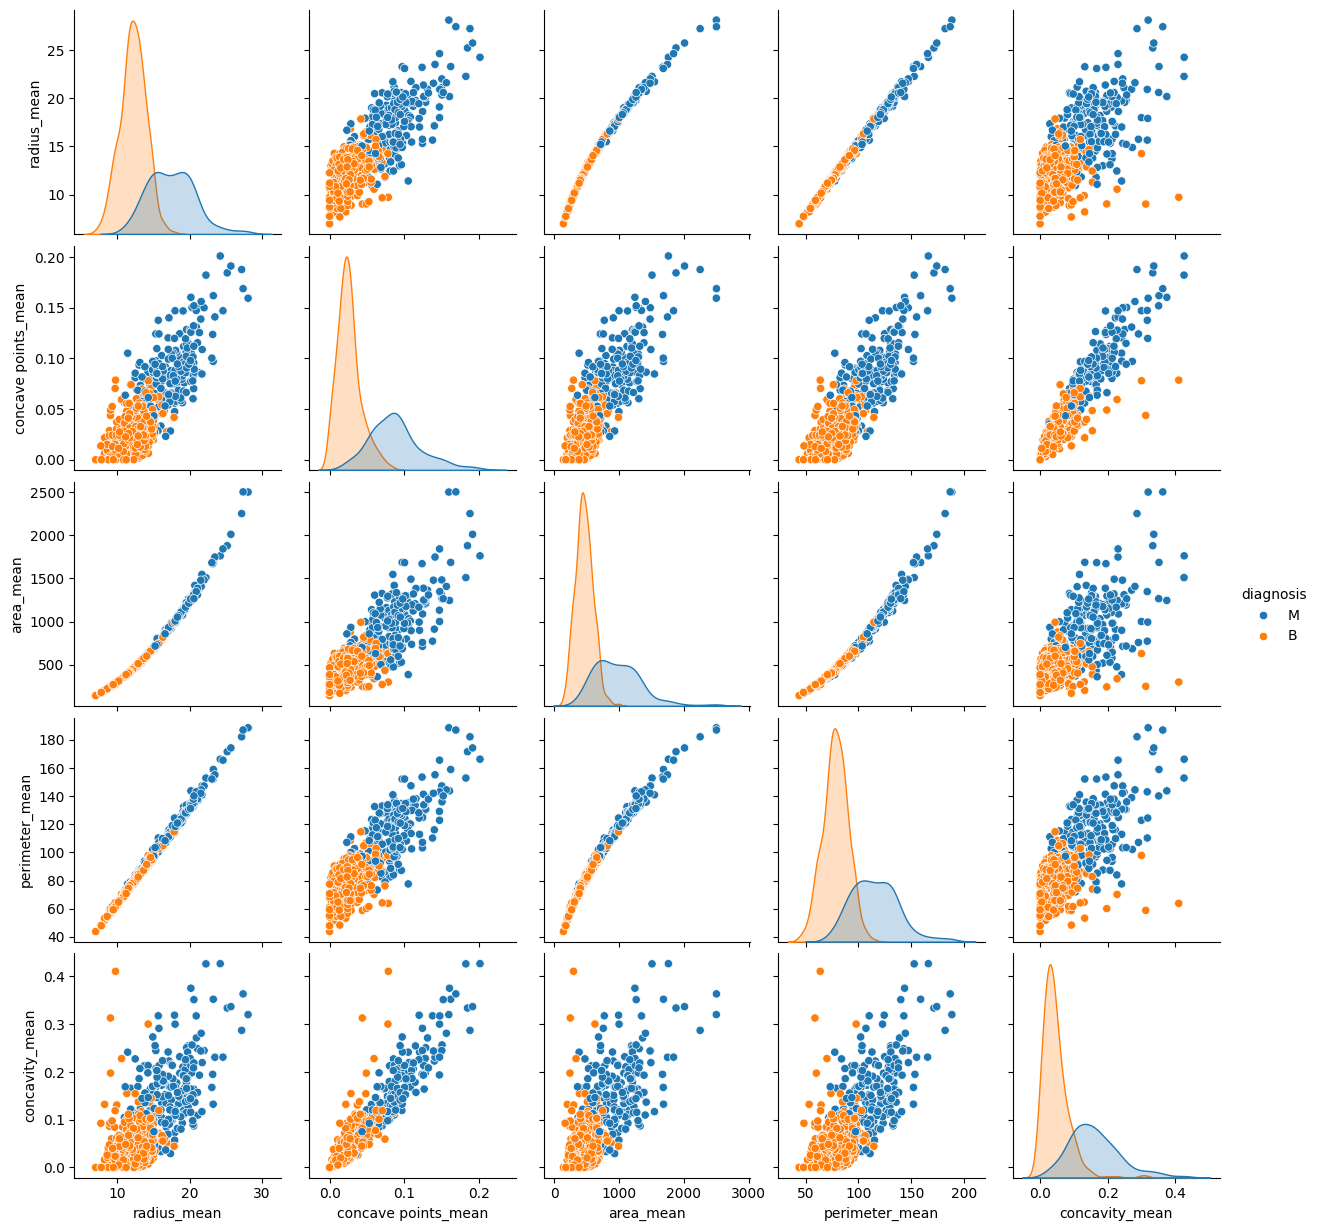

In [24]:
sns.pairplot(for_pairplot,hue='diagnosis')
plt.show()

* Malignant and benign tumors show clear separation in features like radius_mean, area_mean, and concave points_mean.
* Strong positive correlations exist between radius_mean, area_mean, and perimeter_mean, indicating feature redundancy.

## ⚙️ Step 5: Preprocess the Data

In [25]:
# Convert diagnosis column to 0 (benign) and 1 (malignant)

df['diagnosis']=df['diagnosis'].map({'M':1,'B':0})

In [32]:
# Split features and labels

x = df.drop(columns = 'diagnosis')

y = df['diagnosis']

In [36]:
print(x.shape)
print(y.shape)

(569, 30)
(569,)


In [37]:
# Split into training and testing sets

x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2, random_state=42, stratify=y)

In [43]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(455, 30)
(114, 30)
(455,)
(114,)


In [45]:
# Scale the features

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

## 🤖 Step 6: Train a Machine Learning Model

In [49]:
# Use Logistic Regression
LR = LogisticRegression()

LR.fit(x_train_scaled,y_train)

LogisticRegression()

## 🧪 Step 7: Evaluate the Model

In [53]:
# Predict on test data

y_pred = LR.predict(x_test_scaled)

In [54]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9649122807017544

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114


Confusion Matrix:
 [[71  1]
 [ 3 39]]


* The Logistic Regression model achieved 96.5% accuracy, with strong precision and recall for both malignant and benign tumor predictions. Only 4 out of 114 test cases were misclassified, making it a reliable baseline model for breast cancer detection. 

## ✅ Conclusion

Awesome work! 🎉

I've successfully built a breast cancer prediction model using Logistic Regression. I explored the data, cleaned it, visualized it, trained a model, and evaluated its performance.

